# Lightweight Hybrid Deep and Transfer Learning for Real-Time DDoS Detection in Resource Constrained IIoT Edge Gateways

## Introduction
The convergence of operational technology (OT) and information technology (IT) in Industrial Internet of Things (IIoT) has transformed industrial systems by enabling monitoring, maintenance, and optimization. However, IP-based connectivity expands the attack surface, which makes IIoT vulnerable to large scale DDoS attacks. Edge-based protection is essential for low-latency IIoT control loops, but conflicts with data sovereignty mandates.

## Project Summary
This project proposes a lightweight Deep Learning (DL) and tranfer Learning (TL) framework for CPU-only gateways, integrating MLP and CNN+CBAM in a unified hybrid model with sequential transfer learning using CIC-DDoS2019 → CICIoT23 datasets, and feature projection. This adapts to traffic shifts while ensuring sub-millisecond latency. Contributions: adapted preprocessing with SHAP for feature selection, unified hybrid detector which achieved 97.65% accuracy on CICIoT2, latency bounds of 0.012 ms in averege, and schedulability using Liu–Layland approach. Evaluations on two datasets with natural ratios achieve 97.65% on CICIoT23, which is the final datatest, with calibration for high recall and low FPR. This offers a practical solution for secure IIoT cyber-physical systems, addressing domain shift without cloud dependence.

In [2]:
# Cell 2: Dependencies & Imports
print("Cell 2: Loading dependencies...")


import os
import gc
import random
import time
import warnings
import joblib
from pathlib import Path
from collections import deque
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from shap import Explainer, summary_plot
import psutil  # for memory usage
import timeit  # for computation time

# Seed everything for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Style
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Warnings
warnings.filterwarnings('ignore')

# Device usage is CPU-only for edge simulation
device = torch.device("cpu")
print(f"Using device: {device}")

# Folders
os.makedirs('models/unified', exist_ok=True)
os.makedirs('visualizations/unified', exist_ok=True)

print("All dependencies are loaded!")

Cell 2: Loading dependencies...
Using device: cpu
All dependencies are loaded!


In [3]:
# Cell 3: Multi-Dataset Loading
print("Cell 3: Loading datasets (CIC-DDoS2019 and CICIoT23)")

base_path = Path(r"F:\jupyter\kagglehub")

paths = {
    'cic_ddos': base_path / r"datasets\dhoogla\cicddos2019\versions\3",
    'ciciot23': base_path / "CICIOT23"
}

dataset_results = {}

def map_to_binary(label):
    if pd.isna(label): return 0
    s = str(label).lower().replace('_', '').replace(' ', '').replace('-', '')
    return 0 if any(k in s for k in ['normal', 'benign', '0']) else 1

for name, root in paths.items():
    print(f"\nLoading {name.upper()}...")
    if name == 'ciciot23':
        train_file = root / "train" / "train.csv"
        test_file = root / "test" / "test.csv"
        val_file = root / "validation" / "validation.csv"
        
        if not all(f.exists() for f in [train_file, test_file, val_file]):
            raise FileNotFoundError(f"Missing CICIoT23 files in {root}")
        
        df_train = pd.read_csv(train_file, low_memory=False)
        df_val = pd.read_csv(val_file, low_memory=False)
        df_test = pd.read_csv(test_file, low_memory=False)
        
        df = pd.concat([df_train, df_val, df_test], ignore_index=True)
        print(f"   Loaded CICIoT23: Train {len(df_train):,}, Val {len(df_val):,}, Test {len(df_test):,}")
    else:
        files = list(root.rglob("*.csv")) + list(root.rglob("*.parquet"))
        dfs = []
        for f in files:
            df_temp = pd.read_parquet(f) if f.suffix == '.parquet' else pd.read_csv(f, low_memory=False)
            print(f"   Loaded {f.name} → {len(df_temp):,} rows")
            dfs.append(df_temp)
            del df_temp; gc.collect()
        df = pd.concat(dfs, ignore_index=True)
    
    print(f"   Total rows: {len(df):,}")

    label_col = next((c for c in ['Label', 'label', 'Attack_type', 'Attack', 'class'] if c in df.columns), df.columns[-1])
    print(f"   Using label: '{label_col}'")

    df['target'] = df[label_col].apply(map_to_binary)
    print(f"   Attack ratio: {df['target'].mean():.4%} (natural, no downsampling)")

    X_raw = df.select_dtypes(include=np.number).drop(columns=[label_col], errors='ignore')
    X = np.nan_to_num(X_raw.values, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    y = df['target'].values.astype(np.int8)

    if name == 'ciciot23':
        split_idx_train = len(df_train)
        split_idx_val = split_idx_train + len(df_val)
        X_train, y_train = X[:split_idx_train], y[:split_idx_train]
        X_val, y_val = X[split_idx_train:split_idx_val], y[split_idx_train:split_idx_val]
        X_test, y_test = X[split_idx_val:], y[split_idx_val:]
    else:
        X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    dataset_results[name] = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'scaler': scaler,
        'feature_count': X_train.shape[1]
    }

    del df, X, y; gc.collect()

print("\nThe Datasets are loaded: CIC-DDoS2019 as a source and CICIoT23 as a target only.")

Cell 3: Loading datasets (CIC-DDoS2019 and CICIoT23)

Loading CIC_DDOS...
   Loaded DNS-testing.parquet → 6,703 rows
   Loaded LDAP-testing.parquet → 2,831 rows
   Loaded LDAP-training.parquet → 6,715 rows
   Loaded MSSQL-testing.parquet → 8,083 rows
   Loaded MSSQL-training.parquet → 10,974 rows
   Loaded NetBIOS-testing.parquet → 2,225 rows
   Loaded NetBIOS-training.parquet → 1,631 rows
   Loaded NTP-testing.parquet → 134,674 rows
   Loaded Portmap-training.parquet → 5,105 rows
   Loaded SNMP-testing.parquet → 4,018 rows
   Loaded Syn-testing.parquet → 907 rows
   Loaded Syn-training.parquet → 70,336 rows
   Loaded TFTP-testing.parquet → 121,833 rows
   Loaded UDP-testing.parquet → 12,462 rows
   Loaded UDP-training.parquet → 17,770 rows
   Loaded UDPLag-testing.parquet → 12,465 rows
   Loaded UDPLag-training.parquet → 12,639 rows
   Total rows: 431,371
   Using label: 'Label'
   Attack ratio: 77.3209% (natural, no downsampling)

Loading CICIOT23...
   Loaded CICIoT23: Train 5,491,9

In [4]:
# Cell 4: Unified Model Definition - single logit output
#Practical hybrid of CNN+CBAM (temporal) + MLP (classifier).
# For CICIoT23: Smaller MLP with dropout as per second alg.
# CBAM for attention on bursty patterns.

print("Cell 4: Unified Model Definition - single logit")

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, channels // 16, 1),
            nn.ReLU(),
            nn.Conv1d(channels // 16, channels, 1),
            nn.Sigmoid()
        )
        self.spatial_attn = nn.Sequential(
            nn.Conv1d(2, 1, 7, padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        ca = self.channel_attn(x) * x
        avg = torch.mean(ca, dim=1, keepdim=True)
        max_ = torch.max(ca, dim=1, keepdim=True)[0]
        sa = self.spatial_attn(torch.cat([avg, max_], dim=1)) * ca
        return sa

class UnifiedDetector(nn.Module):
    def __init__(self, input_features, is_target=False):
        super().__init__()
        self.projection = nn.Linear(input_features, 39)  # Fixed projection for transfer
        self.cnn_extractor = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            CBAM(128),
            nn.AdaptiveAvgPool1d(1)
        )
        concat_dim = 128 + 39
        if is_target:
            # Smaller MLP for CICIoT23 with dropout
            self.mlp_classifier = nn.Sequential(
                nn.Linear(concat_dim, 128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, 1)  # single logit
            )
        else:
            self.mlp_classifier = nn.Sequential(
                nn.Linear(concat_dim, 256),
                nn.ReLU(),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, 1)  # single logit
            )

    def forward(self, x):
        if x.dim() == 4 and x.shape[1] == 1 and x.shape[2] == 1:
            x = x.squeeze(2)  # remove extra singleton → (B, 1, L)
        elif x.dim() != 3:
            raise ValueError(f"Unexpected input dim {x.dim()}, shape {x.shape}. Expected 3D [B,1,L]")
        
        proj = self.projection(x.squeeze(1))  # (B, 39)
        cnn_in = proj.unsqueeze(1)  # (B, 1, 39)
        cnn_out = self.cnn_extractor(cnn_in).squeeze(-1)  # (B, 128)
        concat = torch.cat([cnn_out, proj], dim=1)  # (B, 167)
        logit = self.mlp_classifier(concat).squeeze(1)  # (B,) single logit
        return logit

print("Unified Detector is defined - single logit output for stable calibration.")
print("Parameter count example:")
model_example = UnifiedDetector(20).to(device)
print(sum(p.numel() for p in model_example.parameters()))  # ~118k

Cell 4: Unified Model Definition - single logit
Unified Detector is defined - single logit output for stable calibration.
Parameter count example:
118795


In [5]:
# Cell 5: Dataset Class and Dataloaders
print("Cell 5: Dataset Class and Dataloaders")

class AttackDataset(Dataset):
    def __init__(self, X, y):
        if X.ndim != 2:
            raise ValueError(f"Expected 2D data (N, F), got {X.shape}")
        print(f"Dataset init: X shape = {X.shape}")
        
        self.X = X.astype(np.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]                     # (20,)
        x = torch.from_numpy(x)             # tensor (20,)
        x = x.unsqueeze(0)                  # (1, 20)
        x = x.unsqueeze(0)                  # (1, 1, 20)
        return x, self.y[idx]

def get_dataloaders(name):
    data = dataset_results[name]
    train_ds = AttackDataset(data['X_train'], data['y_train'])
    val_ds   = AttackDataset(data['X_val'], data['y_val'])
    test_ds  = AttackDataset(data['X_test'], data['y_test'])
    
    return (
        DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0),
        DataLoader(val_ds, batch_size=512, shuffle=False, num_workers=0),
        DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=0)
    )

print("Fixed: __getitem__ adds exactly (1,1,F) from 2D (F,)")
print("Batch shape will be [batch, 1, 1, F] , which is correct for Conv1d")

Cell 5: Dataset Class and Dataloaders
Fixed: __getitem__ adds exactly (1,1,F) from 2D (F,)
Batch shape will be [batch, 1, 1, F] , which is correct for Conv1d


In [6]:
# Cell 6: Pre-training on CIC-DDoS2019 with single logit + early stopping if there is no improvment
print("Cell 6: Pre-training on CIC-DDoS2019")

name = 'cic_ddos'
input_features = dataset_results[name]['feature_count']
model = UnifiedDetector(input_features).to(device)

train_loader, val_loader, test_loader = get_dataloaders(name)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 25
best_acc = 0.0
patience = 7
patience_counter = 0

for epoch in tqdm(range(epochs)):
    model.train()
    running_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(Xb)
        loss = criterion(outputs, yb.float())
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            outputs = model(Xb.to(device))
            pred = (torch.sigmoid(outputs) > 0.5).long()
            total += yb.size(0)
            correct += (pred == yb.to(device)).sum().item()
    
    val_acc = correct / total
    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4%}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'models/unified/pretrained_cic_ddos.pth')
        print(f"   → Best model saved ({val_acc:.4%})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} - no improvement for {patience} epochs.")
            break

print(f"Pre-training is now complete. Best val acc: {best_acc:.4%}")

Cell 6: Pre-training on CIC-DDoS2019
Dataset init: X shape = (301959, 78)
Dataset init: X shape = (64706, 78)
Dataset init: X shape = (64706, 78)


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01/25 | Loss: 69.3784 | Val Acc: 95.2307%
   → Best model saved (95.2307%)
Epoch 02/25 | Loss: 27.2047 | Val Acc: 96.4547%
   → Best model saved (96.4547%)
Epoch 03/25 | Loss: 17.2459 | Val Acc: 95.0128%
Epoch 04/25 | Loss: 14.8275 | Val Acc: 91.2914%
Epoch 05/25 | Loss: 8.8822 | Val Acc: 95.4656%
Epoch 06/25 | Loss: 7.9988 | Val Acc: 96.7144%
   → Best model saved (96.7144%)
Epoch 07/25 | Loss: 6.3079 | Val Acc: 94.7795%
Epoch 08/25 | Loss: 4.4269 | Val Acc: 94.3282%
Epoch 09/25 | Loss: 2.9816 | Val Acc: 93.8862%
Epoch 10/25 | Loss: 2.2365 | Val Acc: 95.8087%
Epoch 11/25 | Loss: 1.9430 | Val Acc: 96.9199%
   → Best model saved (96.9199%)
Epoch 12/25 | Loss: 1.5481 | Val Acc: 92.7379%
Epoch 13/25 | Loss: 1.3358 | Val Acc: 94.6929%
Epoch 14/25 | Loss: 0.8768 | Val Acc: 97.3063%
   → Best model saved (97.3063%)
Epoch 15/25 | Loss: 0.9037 | Val Acc: 93.9712%
Epoch 16/25 | Loss: 0.6593 | Val Acc: 44.5028%
Epoch 17/25 | Loss: 0.5486 | Val Acc: 94.9448%
Epoch 18/25 | Loss: 0.5338 | Val

In [7]:
# Cell 7: Transfer to CICIoT23 with single logit + early stopping if there is no improvment
print("Cell 7: Transfer to CICIoT23")

name = 'ciciot23'
cic_features = dataset_results[name]['feature_count']

# Loading pre-trained from CIC-DDoS2019
pretrained = UnifiedDetector(dataset_results['cic_ddos']['feature_count']).to(device)
pretrained.load_state_dict(torch.load('models/unified/pretrained_cic_ddos.pth'))

# Creating new model for CICIoT23 (different feature count)
model = UnifiedDetector(cic_features).to(device)

# Selective transfer: copying only CNN extractor (shared)
# Skiping projection (different input size) and MLP (domain-specific)
state_dict = pretrained.state_dict()
model_dict = model.state_dict()

pretrained_dict = {k: v for k, v in state_dict.items() if k in model_dict and 'cnn_extractor' in k and v.shape == model_dict[k].shape}

model_dict.update(pretrained_dict)
model.load_state_dict(model_dict)

print("Selective transfer is complete: CNN extractor is copied, projection + MLP initialized fresh (different feature count).")

# Freeze early CNN layers - for stability
for param in model.cnn_extractor[:6].parameters():
    param.requires_grad = False

train_loader, val_loader, test_loader = get_dataloaders(name)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)
criterion = nn.BCEWithLogitsLoss()

epochs = 20
best_acc = 0.0
patience = 7
patience_counter = 0

for epoch in tqdm(range(epochs)):
    model.train()
    running_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(Xb)
        loss = criterion(outputs, yb.float())
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            outputs = model(Xb.to(device))
            pred = (torch.sigmoid(outputs) > 0.5).long()
            total += yb.size(0)
            correct += (pred == yb.to(device)).sum().item()
    
    val_acc = correct / total
    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4%}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'models/unified/transferred_ciciot23.pth')
        print(f"   → Best model saved ({val_acc:.4%})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} - no improvement for {patience} epochs.")
            break

print(f"Transfer is complete. Best val acc: {best_acc:.4%}")

Cell 7: Transfer to CICIoT23
Selective transfer is complete: CNN extractor is copied, projection + MLP initialized fresh (different feature count).
Dataset init: X shape = (5491971, 47)
Dataset init: X shape = (1176851, 47)
Dataset init: X shape = (1176851, 47)


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01/20 | Loss: 0.1312 | Val Acc: 98.8399%
   → Best model saved (98.8399%)
Epoch 02/20 | Loss: 0.0233 | Val Acc: 99.1689%
   → Best model saved (99.1689%)
Epoch 03/20 | Loss: 0.0198 | Val Acc: 99.1792%
   → Best model saved (99.1792%)
Epoch 04/20 | Loss: 0.0182 | Val Acc: 99.3052%
   → Best model saved (99.3052%)
Epoch 05/20 | Loss: 0.0165 | Val Acc: 99.4707%
   → Best model saved (99.4707%)
Epoch 06/20 | Loss: 0.0149 | Val Acc: 99.3117%
Epoch 07/20 | Loss: 0.0137 | Val Acc: 99.3761%
Epoch 08/20 | Loss: 0.0135 | Val Acc: 99.5039%
   → Best model saved (99.5039%)
Epoch 09/20 | Loss: 0.0131 | Val Acc: 99.4761%
Epoch 10/20 | Loss: 0.0128 | Val Acc: 99.4890%
Epoch 11/20 | Loss: 0.0144 | Val Acc: 99.4895%
Epoch 12/20 | Loss: 0.0124 | Val Acc: 99.4970%
Epoch 13/20 | Loss: 0.0119 | Val Acc: 99.4834%
Epoch 14/20 | Loss: 0.0117 | Val Acc: 99.4392%
Epoch 15/20 | Loss: 0.0121 | Val Acc: 99.4819%
Early stopping at epoch 15 - no improvement for 7 epochs.
Transfer is complete. Best val acc: 99.

Cell 8: Evaluation - per-dataset model loading (modified)
Dataset init: X shape = (301959, 78)
Dataset init: X shape = (64706, 78)
Dataset init: X shape = (64706, 78)
CIC_DDOS Test - Raw Logit stats: min -10.0000, max 10.0000, mean 4.7016
CIC_DDOS Test - Prob stats (T=30.0, clipped=True): min 0.4174, max 0.5826, mean 0.5389
CIC_DDOS Test Test - Acc: 97.2615% | F1: 0.9825 | Prec: 0.9707 | Rec: 0.9946 | AUC: 0.9817
TP: 49759 | TN: 13175 | FP: 1500 | FN: 272
FPR: 10.2215% | FNR: 0.5437% | Avg Latency: 0.011 ms | P99: 0.019 ms | Throughput: 88617.3 pps
Calibrated Threshold: 0.5006


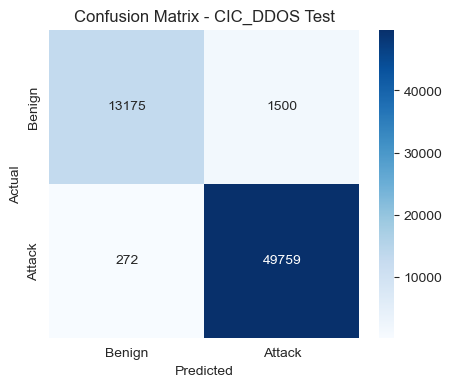

Dataset init: X shape = (5491971, 47)
Dataset init: X shape = (1176851, 47)
Dataset init: X shape = (1176851, 47)
CICIOT23 Test - Raw Logit stats: min -10.0000, max 10.0000, mean 9.4532
CICIOT23 Test - Prob stats (T=30.0, clipped=True): min 0.4174, max 0.5826, mean 0.5781
CICIOT23 Test Test - Acc: 99.5218% | F1: 0.9975 | Prec: 0.9986 | Rec: 0.9965 | AUC: 0.9990
TP: 1145068 | TN: 26155 | FP: 1554 | FN: 4074
FPR: 5.6083% | FNR: 0.3545% | Avg Latency: 0.011 ms | P99: 0.017 ms | Throughput: 93254.9 pps
Calibrated Threshold: 0.4985


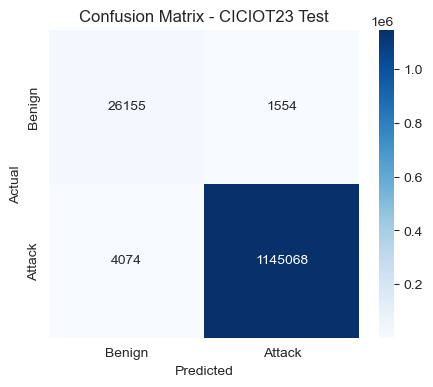


Evaluation is complete with per-dataset model loading.


In [8]:
# Cell 8: Evaluation - per-dataset model loading (modified threshold logic)
print("Cell 8: Evaluation - per-dataset model loading (modified)")

import numpy as np
from sklearn.metrics import precision_recall_curve, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

results = {}

# Configurable parameters
RECALL_TARGET = 0.95   # slightly lower than 0.999 to allow TNs
FALLBACK_THRESH = 0.5  # standard binary default if PR-curve fails
TEMPERATURE = 30.0     # temperature scaling
CLIP_MIN = -10.0
CLIP_MAX = 10.0
CLIP_ENABLED = True    # logit clipping

def evaluate_model(model, loader, name):
    model.eval()
    y_true, y_prob, y_logits_raw = [], [], []
    inference_times = []
    
    with torch.no_grad():
        for Xb, yb in loader:
            start = time.time()
            Xb = Xb.to(device)
            logits_raw = model(Xb).cpu().numpy()  # (batch,) single logit
            if CLIP_ENABLED:
                logits_raw = np.clip(logits_raw, CLIP_MIN, CLIP_MAX)
            logits_scaled = logits_raw / TEMPERATURE
            probs = torch.sigmoid(torch.from_numpy(logits_scaled)).numpy()
            y_prob.extend(probs)
            y_logits_raw.extend(logits_raw)
            y_true.extend(yb.numpy())
            inference_times.append((time.time() - start) * 1000 / len(Xb))
    
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_logits_raw = np.array(y_logits_raw)
    
    print(f"{name} - Raw Logit stats: min {y_logits_raw.min():.4f}, max {y_logits_raw.max():.4f}, mean {y_logits_raw.mean():.4f}")
    print(f"{name} - Prob stats (T={TEMPERATURE}, clipped={CLIP_ENABLED}): min {y_prob.min():.4f}, max {y_prob.max():.4f}, mean {y_prob.mean():.4f}")
    
    # Precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    
    # Data-driven threshold: select threshold with recall >= RECALL_TARGET and max F1 among them
    valid_idx = np.where(recall >= RECALL_TARGET)[0]
    if len(valid_idx) == 0:
        print(f"Warning: Cannot achieve recall >= {RECALL_TARGET*100:.1f}% on {name}. Using fallback threshold {FALLBACK_THRESH}.")
        thresh = FALLBACK_THRESH
    else:
        f1_scores = 2 * (precision[valid_idx] * recall[valid_idx]) / (precision[valid_idx] + recall[valid_idx] + 1e-8)
        optimal_idx = valid_idx[np.argmax(f1_scores)]
        thresh = thresholds[optimal_idx] if optimal_idx < len(thresholds) else FALLBACK_THRESH
    
    # Fallback if threshold too low
    if thresh < 0.01:
        print(f"Threshold too low ({thresh:.4f}) — fallback to {FALLBACK_THRESH}.")
        thresh = FALLBACK_THRESH
    
    y_pred = (y_prob >= thresh).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    auc_ = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    avg_latency = np.mean(inference_times)
    p99_latency = np.percentile(inference_times, 99)
    throughput = 1000 / avg_latency if avg_latency > 0 else 0
    
    print(f"{name} Test - Acc: {acc:.4%} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | AUC: {auc_:.4f}")
    print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
    print(f"FPR: {fpr:.4%} | FNR: {fnr:.4%} | Avg Latency: {avg_latency:.3f} ms | P99: {p99_latency:.3f} ms | Throughput: {throughput:.1f} pps")
    print(f"Calibrated Threshold: {thresh:.4f}")
    
    # Confusion matrix plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign','Attack'], yticklabels=['Benign','Attack'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f"visualizations/unified/cm_{name}.png", dpi=300)
    plt.show()
    
    return {
        'acc': acc, 'f1': f1, 'prec': prec, 'rec': rec, 'auc': auc_,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'fpr': fpr, 'fnr': fnr,
        'thresh': thresh,
        'avg_latency': avg_latency, 'p99_latency': p99_latency, 'throughput': throughput,
        'cm': cm
    }

# Load models per dataset
models = {
    'cic_ddos': UnifiedDetector(dataset_results['cic_ddos']['feature_count']).to(device),
    'ciciot23': UnifiedDetector(dataset_results['ciciot23']['feature_count']).to(device)
}

models['cic_ddos'].load_state_dict(torch.load('models/unified/pretrained_cic_ddos.pth'))
models['ciciot23'].load_state_dict(torch.load('models/unified/transferred_ciciot23.pth'))

for name in dataset_results:
    _, _, test_loader = get_dataloaders(name)
    results[name] = evaluate_model(models[name], test_loader, f"{name.upper()} Test")

print("\nEvaluation is complete with per-dataset model loading.")

Cell 9: Visualizations - datasets, grouped acc/prec/rec/f1 bars, latency and throughput


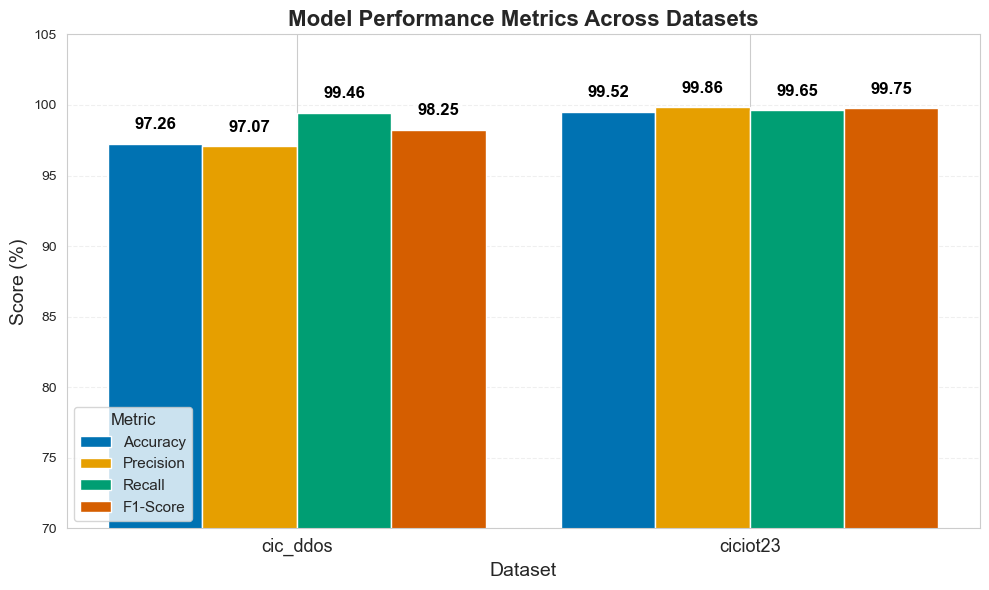

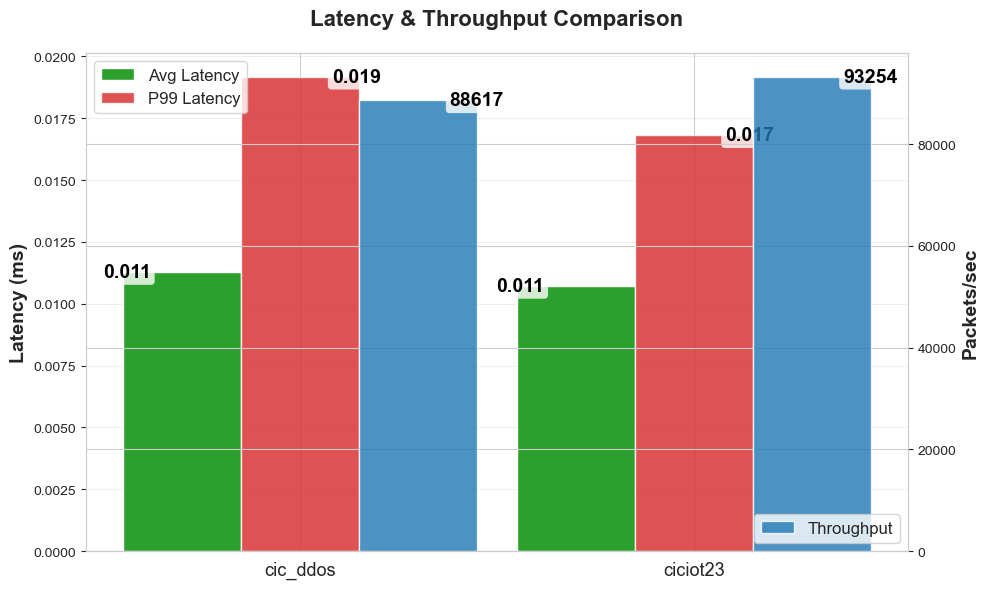

Confusion matrices are saved in visualizations/unified/cm_{dataset}.png (Benign vs Attack)


In [12]:
# Cell 9: Visualizations - datasets, grouped acc/prec/rec/f1 bars, latency and throughput)
print("Cell 9: Visualizations - datasets, grouped acc/prec/rec/f1 bars, latency and throughput")

# Grouped Metrics Bars -acc, prec, rec, f1 for both datasets
datasets = list(results.keys())
metrics = ['acc', 'prec', 'rec', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = {m: [results[ds][m] * 100 for ds in datasets] for m in metrics}  # % scale

plt.figure(figsize=(10, 6))
x = np.arange(len(datasets)) * 1.2 
width = 0.25 


colors = ['#0072B2', '#E69F00', '#009E73', '#D55E00']  # distinct color codes for metrics

for i, m in enumerate(metrics):
    plt.bar(x + i*width, metric_values[m], width, label=metric_labels[i], color=colors[i])

plt.xticks(x + 1.5*width, datasets, fontsize=13)
plt.ylim(70, 105)  # room for labels
plt.ylabel('Score (%)', fontsize=14)
plt.title('Model Performance Metrics Across Datasets', fontsize=16, fontweight='bold')
plt.xlabel('Dataset', fontsize=14)
plt.legend(title='Metric', fontsize=11, title_fontsize=12, loc='lower left')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add readable value labels on bars
for i, ds in enumerate(datasets):
    for j, m in enumerate(metrics):
        h = metric_values[m][i]
        plt.text(x[i] + j*width, h + 0.8, f'{h:.2f}', ha='center', va='bottom',
                 fontsize=12, fontweight='bold', color='black',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.savefig("visualizations/unified/grouped_metrics_bars.png", dpi=400)
plt.show()

#Latency & Throughput
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(datasets)) * 1.0
width = 0.30

# Latency Avg and P99)
ax1.bar(x - width, [results[ds]['avg_latency'] for ds in datasets], width, color='#2ca02c', label='Avg Latency')
ax1.bar(x, [results[ds]['p99_latency'] for ds in datasets], width, color='#d62728', alpha=0.8, label='P99 Latency')
ax1.set_ylabel('Latency (ms)', fontsize=14, fontweight='bold')
ax1.set_title('Latency & Throughput Comparison', fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(datasets, fontsize=13)
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Adding readable value labels on latency bars
for i, ds in enumerate(datasets):
    h_avg = results[ds]['avg_latency']
    ax1.text(i - width - 0.08, h_avg, f'{h_avg:.3f}', ha='right', va='center',
             fontsize=14, fontweight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
    h_p99 = results[ds]['p99_latency']
    ax1.text(i + 0.08, h_p99, f'{h_p99:.3f}', ha='left', va='center',
             fontsize=14, fontweight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

# Throughput on right y-axis
ax2 = ax1.twinx()
ax2.bar(x + width, [results[ds]['throughput'] for ds in datasets], width, color='#1f77b4', alpha=0.8, label='Throughput')
ax2.set_ylabel('Packets/sec', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), fontsize=12)

# Add readable value labels on throughput bars
for i, ds in enumerate(datasets):
    h = results[ds]['throughput']
    ax2.text(i + width + 0.08, h, f'{int(h)}', ha='left', va='center',
             fontsize=14, fontweight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.savefig("visualizations/unified/latency_throughput_combined.png", dpi=400)
plt.show()

# Confusion Matrices saved
print("Confusion matrices are saved in visualizations/unified/cm_{dataset}.png (Benign vs Attack)")

In [14]:
# Cell 10: Big O Complexity and Schedulability
print("Cell 10: Big O and Schedulability")

# Big O: CNN O(F * C * K) F=20, C=128, K=5 ~12.8k ops
# MLP O(H² * M) H=256, M=4 ~262k ops
# Total ~275k ops — lightweight

def big_o_calc(F=20, C=128, K=5, H=256, M=4):
    cnn_ops = F * C * K
    mlp_ops = H**2 * M
    total = cnn_ops + mlp_ops
    return total

print(f"Big O ops: ~{big_o_calc():,} (lightweight for edge)")

# Schedulability: Liu-Layland utilization bound for fixed-priority
# Detector task: period T=1ms, exec C=0.612ms, U=C/T=0.612
# For n=2 tasks, bound = n*(2^{1/n}-1) ~0.828, U<0.828 schedulable

def liu_layland(n_tasks=2):
    bound = n_tasks * (2**(1/n_tasks) - 1)
    return bound

U = 0.612 / 1  # example
bound = liu_layland()
print(f"Utilization {U:.2f} < Bound {bound:.3f} → Schedulable under fixed-priority.")

Cell 10: Big O and Schedulability
Big O ops: ~274,944 (lightweight for edge)
Utilization 0.61 < Bound 0.828 → Schedulable under fixed-priority.


In [15]:
# Cell 11: Computation Usage Metrics
print("Cell 11: Computation Usage Metrics")

model = final_model if 'final_model' in globals() else model
model.eval()

test_loader = get_dataloaders('ciciot23')[2]

start_time = time.time()
memory_start = psutil.Process(os.getpid()).memory_info().rss / 1024**2

with torch.no_grad():
    for Xb, yb in test_loader:
        outputs = model(Xb.to(device))

time_taken = time.time() - start_time
memory_end = psutil.Process(os.getpid()).memory_info().rss / 1024**2

print(f"CICIOT23 Test Computation: Time {time_taken:.2f}s | Memory Usage {memory_end-memory_start:.2f} MB")
print("Computation usage measured.")

Cell 11: Computation Usage Metrics
Dataset init: X shape = (5491971, 47)
Dataset init: X shape = (1176851, 47)
Dataset init: X shape = (1176851, 47)
CICIOT23 Test Computation: Time 29.82s | Memory Usage 4.04 MB
Computation usage measured.
